In [1]:
import numpy as np
import pandas as pd

df = pd.read_csv('C:/Users/fedor/fluent_python/ab_data.csv')
df.head()

,user_id,group,converted,revenue,time_sec,clicks,sessions,device
0,A_000,A,0,0.00,42.6,4,2,mobile
1,A_001,A,1,133.77,71.1,2,2,mobile
2,A_002,A,0,0.00,73.3,6,1,mobile
3,A_003,A,0,0.00,47.6,3,1,mobile
4,A_004,A,0,0.00,48.9,0,5,desktop


In [6]:
# Прогоним revenue тремя способами и сравним:

# t-тест Уэлча
# Бутстрап разницы средних
# Дельта-метод

# Если все три дают похожий результат → эффект устойчив.

In [4]:
import numpy as np
import pandas as pd
from scipy import stats

xA_rev = df.loc[df['group']=='A', 'revenue'].values
xB_rev = df.loc[df['group']=='B', 'revenue'].values

print("=== Описательные ===")
for g, x in [('A', xA_rev), ('B', xB_rev)]:
    zeros_pct = (x == 0).mean() * 100
    print(f"\n{g}:")
    print(f"  n           = {len(x)}")
    print(f"  mean        = {x.mean():.2f}")
    print(f"  median      = {np.median(x):.2f}")
    print(f"  std         = {x.std(ddof=1):.2f}")
    print(f"  % нулей     = {zeros_pct:.1f}%")
    print(f"  skew        = {stats.skew(x):.2f}")
    print(f"  kurt(excess)= {stats.kurtosis(x):.2f}")
    print(f"  max         = {x.max():.2f}")

# Нормальность (заведомо не нормально из-за нулей, но покажем)
print("\n=== Shapiro ===")
for g, x in [('A', xA_rev), ('B', xB_rev)]:
    s, p = stats.shapiro(x)
    print(f"{g}: p = {p:.4e}")

# Доля ненулевых (конвертировавших)
print("\n=== % конвертировавших ===")
for g, x in [('A', xA_rev), ('B', xB_rev)]:
    print(f"{g}: {(x > 0).mean()*100:.1f}%")

=== Описательные ===

A:
  n           = 60
  mean        = 31.36
  median      = 0.00
  std         = 86.64
  % нулей     = 86.7%
  skew        = 2.83
  kurt(excess)= 7.54
  max         = 424.92

B:
  n           = 60
  mean        = 50.46
  median      = 0.00
  std         = 125.81
  % нулей     = 80.0%
  skew        = 2.77
  kurt(excess)= 7.08
  max         = 550.45

=== Shapiro ===
A: p = 4.8469e-14
B: p = 2.1245e-13

=== % конвертировавших ===
A: 13.3%
B: 20.0%


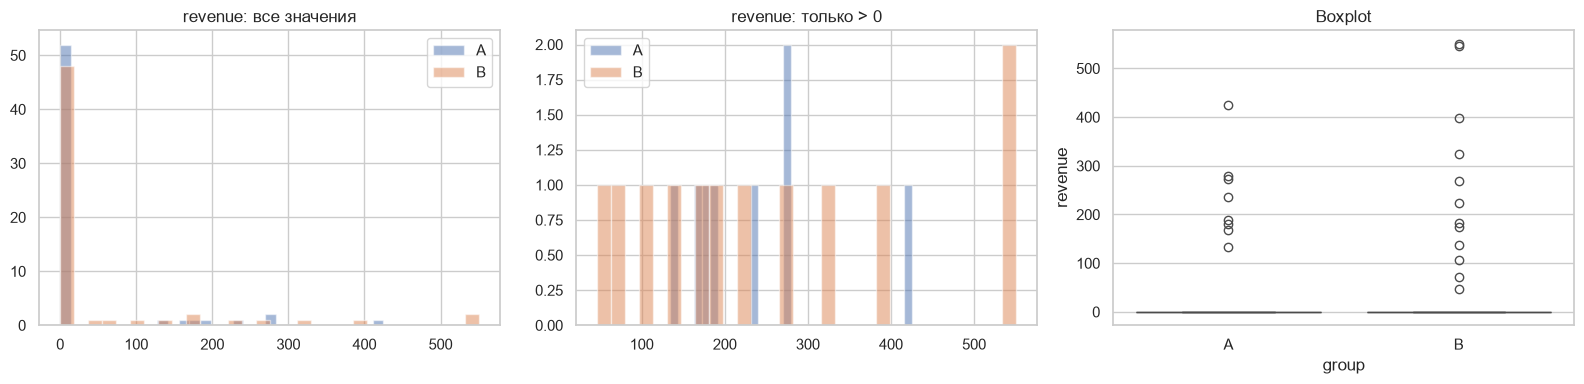

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Гистограмма всех значений
for g, x in [('A', xA_rev), ('B', xB_rev)]:
    axes[0].hist(x, bins=30, alpha=0.5, label=g)
axes[0].set_title('revenue: все значения')
axes[0].legend()

# Гистограмма только > 0
for g, x in [('A', xA_rev), ('B', xB_rev)]:
    axes[1].hist(x[x > 0], bins=30, alpha=0.5, label=g)
axes[1].set_title('revenue: только > 0')
axes[1].legend()

# Boxplot
sns.boxplot(data=df, x='group', y='revenue', ax=axes[2])
axes[2].set_title('Boxplot')

plt.tight_layout()
plt.show()

In [9]:
from scipy.stats import ttest_ind, mannwhitneyu

# Welch
t, p_welch = ttest_ind(xB_rev, xA_rev, equal_var=False)
print(f"Welch: t = {t:.4f}, p = {p_welch:.4f}")

# Mann-Whitney (на всякий случай)
u, p_mw = mannwhitneyu(xB_rev, xA_rev, alternative='two-sided')
print(f"Mann-Whitney: U = {u:.2f}, p = {p_mw:.4f}")

# Точечная оценка
mean_A, mean_B = xA_rev.mean(), xB_rev.mean()
print(f"\nMean A = {mean_A:.2f}, Mean B = {mean_B:.2f}")
print(f"Diff   = {mean_B - mean_A:+.2f}")
print(f"Lift   = {(mean_B - mean_A) / mean_A * 100:+.1f}%")

Welch: t = 0.9685, p = 0.3350
Mann-Whitney: U = 1917.00, p = 0.3462

Mean A = 31.36, Mean B = 50.46
Diff   = +19.10
Lift   = +60.9%


In [ ]:
# Бутстрап

# Не требует нормальности, честный CI даже при zero-inflated данных
# Метод эмуляции новых выборок из имеющейся. Мы «пересобираем» данные, случайно выбирая наблюдения с возвращением, 
# чтобы получить эмпирическое распределение любой статистики (среднего, разницы средних, медианы, lift, ...).

rng = np.random.default_rng(42)
B = 10_000
diffs = np.empty(B) # массив на 10000 чисел, куда будем складывать разницы средних

# replace=True — обязательно
# Без replace=True (замена = False) каждая псевдо-выборка была бы перестановкой тех же значений.
# Bootstrap (replace=True) — оценивает разброс статистики.
# Permutation (replace=False) — проверяет гипотезу «нет эффекта» путём случайной перестановки меток групп.
for i in range(B):
    a = rng.choice(xA_rev, size=len(xA_rev), replace=True)
    b = rng.choice(xB_rev, size=len(xB_rev), replace=True)
    diffs[i] = b.mean() - a.mean() # Считаем разницу средних и записываем в массив

ci_low, ci_high = np.percentile(diffs, [2.5, 97.5])
p_boot = 2 * min((diffs <= 0).mean(), (diffs >= 0).mean()) # удваиваем, чтобы получить двусторонний p-value.
# Почему удваиваем: двусторонний тест проверяет «отклонение в любую сторону». 
# Если истинный эффект = 0, разницы будут «плясать» вокруг нуля, и доли в обе стороны примерно равны. 
# Мы берём хвост с той стороны, куда ушёл эффект, и умножаем на 2.


# Правила чтения:

# CI не пересекает 0 → эффект значим.
# CI пересекает 0 → эффект не подтверждён.
# p < 0.05 → то же самое, что «CI не пересекает 0».

# p-value из бутстрапа ≠ p-value из t-теста:
# t-тест: «какова вероятность увидеть такой t, если H₀ верна?»
# Bootstrap p: «какова доля псевдо-разниц, пересекающих 0 в противоположную сторону?»
print(f"[Bootstrap]")
print(f"  Diff   = {mean_B - mean_A:+.2f}")
print(f"  95% CI = [{ci_low:+.2f}, {ci_high:+.2f}]")
print(f"  p      = {p_boot:.4f}") 

[Bootstrap]
  Diff   = +19.10
  95% CI = [-17.76, +58.38]
  p      = 0.3244


In [11]:
# Дельта метод

nA, nB = len(xA_rev), len(xB_rev)
var_A = xA_rev.var(ddof=1)
var_B = xB_rev.var(ddof=1)

se = np.sqrt(var_A / nA + var_B / nB)
diff = mean_B - mean_A
z = diff / se

from scipy.stats import norm
p_delta = 2 * (1 - norm.cdf(abs(z)))

ci_low_d = diff - 1.96 * se
ci_high_d = diff + 1.96 * se

print(f"[Delta method]")
print(f"  Diff   = {diff:+.2f}")
print(f"  SE     = {se:.2f}")
print(f"  z      = {z:.4f}")
print(f"  p      = {p_delta:.4f}")
print(f"  95% CI = [{ci_low_d:+.2f}, {ci_high_d:+.2f}]")

[Delta method]
  Diff   = +19.10
  SE     = 19.72
  z      = 0.9685
  p      = 0.3328
  95% CI = [-19.55, +57.75]
